In [ ]:
!pip install -q langchain langchain_openai langchain-core langchain-community langchain-huggingface openai

In [3]:
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEndpoint


### Task 1: Call LLM with a basic prompt

Make it possible to invoke LLM with a plain text prompt.

The prompt should allow you to get information in plain language on a certain topic. In this task, we want to learn about the topic "Quantum computing".

The model response should include a definition, key benefits, and current research in the field.

Limit the answer to 200 characters and write in the prompt so that the answer is short.

As an LLM, you can use both a model with HugginFace (I recommend Mistral), and ChatGPT4 or ChatGPT3. In both cases, you need to import the necessary "wrapper" (that is, the class that will allow you to initiate the model) from LangChain to call LLM via the API, as well as read a personal token from a file, for example, `creds.json`, which is located locally.

Set your temperature value as you see fit (there is no right or wrong value here) and write why you chose that value for this exercise.

In [13]:
import json
import os

with open('creds.json') as file:
  creds = json.load(file)

os.environ["OPENAI_API_KEY"] = creds["OPENAI_API_KEY"]
os.environ["HF_TOKEN"] = creds['HUGGINGFACEHUB_API_TOKEN']
os.environ["SERPAPI_API_KEY"] = creds["SERPAPI_API_KEY"]

We need output to be predictable and precise, but with a little creativity, so lets set temperature to `0.1`

In [5]:
overal_temperature = 0.1

In [6]:
request = 'Briefly explain “quantum computing.” Include: definition, key advantages, and current research. Keep the response very short and concise.'

####GPT4

In [41]:
gpt_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=overal_temperature,
    max_tokens=200
)

In [7]:
gpt_response = gpt_llm.invoke(request)

In [9]:
gpt_response.content

'**Definition:** Quantum computing is a type of computation that utilizes quantum bits (qubits) to perform calculations based on the principles of quantum mechanics, allowing for the simultaneous processing of multiple possibilities.\n\n**Key Advantages:**\n1. **Speed:** Quantum computers can solve complex problems much faster than classical computers.\n2. **Parallelism:** They can process a vast number of possibilities at once due to superposition.\n3. **Efficiency:** Quantum algorithms can outperform classical algorithms in specific tasks, such as factoring large numbers and simulating quantum systems.\n\n**Current Research:** Ongoing research focuses on improving qubit stability and coherence, developing error correction methods, and exploring applications in cryptography, materials science, and optimization problems. Major tech companies and academic institutions are actively working on building scalable quantum systems.'

####LLAMA

In [9]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

llama_llm = HuggingFaceEndpoint(
  repo_id="meta-llama/Llama-3.1-8B-Instruct",
  temperature=overal_temperature,
  max_new_tokens=200
)

llama = ChatHuggingFace(llm=llama_llm)

llama_prompt = ChatPromptTemplate.from_messages([
  SystemMessagePromptTemplate.from_template("You're a helpful assistant."),
  HumanMessagePromptTemplate.from_template("{user_question}"),
])

llama_chain = llama_prompt | llama

llama_response = llama_chain.invoke({"user_question": request })

print(llama_response.content)

**Definition:** Quantum computing is a type of computing that uses the principles of quantum mechanics to perform calculations and operations on data.

**Key Advantages:**

1. **Faster processing**: Quantum computers can process complex calculations exponentially faster than classical computers.
2. **Parallel processing**: Quantum computers can perform multiple calculations simultaneously, increasing efficiency.
3. **Enhanced security**: Quantum computers can break certain classical encryption algorithms, but they can also create unbreakable quantum encryption.

**Current Research:** Researchers are exploring applications of quantum computing in fields like:

1. **Cryptography**: Developing quantum-resistant encryption algorithms.
2. **Optimization**: Solving complex optimization problems in fields like logistics and finance.
3. **Materials science**: Simulating materials behavior at the atomic level.

Quantum computing has the potential to revolutionize various industries, but signifi

### Task 2: Creating a parameterized prompt for text generation
Now we want to update the previous functional so that we can pass the topic as a parameter to the prompt. To do this, use `PromptTemplate` from `langchain` and implement a parameterized prompt and call model with it.

Run the updated functionality (prompt + model) for topic explanations
- "Bayesian methods in machine learning"
- "Transformers in machine learning"
- "Explainable AI"

Display the results of model on the screen.

In [26]:
from langchain_core.prompts import PromptTemplate

In [32]:
prompt = PromptTemplate(
    input_variables=["theme"],
    template=("Give a definition of {theme}, key advantages, "
              "and current research. Keep the response very short and concise.")
)

In [33]:
for theme in ["Bayesian methods in Machine Learning",
              "Transformers in Machine Learning",
              "Explainable AI"]:
    print(f"-----{theme}-----")
    print(llama_chain.invoke(prompt.format(theme=theme)).content)
    print("")

-----Bayesian methods in Machine Learning-----
**Definition:** Bayesian methods in Machine Learning involve using Bayes' theorem to update the probability of a model's parameters given new data, incorporating prior knowledge and uncertainty into the learning process.

**Key Advantages:**

1. **Uncertainty estimation**: Quantifies model uncertainty through probability distributions.
2. **Regularization**: Automatic regularization through prior distributions.
3. **Flexibility**: Can handle non-linear relationships and complex models.

**Current Research:**

1. **Deep Bayesian networks**: Applying Bayesian methods to deep neural networks.
2. **Bayesian transfer learning**: Transfering knowledge between tasks using Bayesian methods.
3. **Uncertainty-aware decision-making**: Using Bayesian methods for decision-making under uncertainty.

-----Transformers in Machine Learning-----
**Definition:** 
Transformers are a type of deep learning model primarily used for natural language processing (N



### Task 3: Using an agent to automate processes
Create an agent that helps you automatically search for information about the latest scientific publications in various fields. For example, an agent should find the 5 latest publications on the topic of artificial intelligence.

**Steps:**
1. Configure a ReAct agent in LangChain to perform automatic requests.
2. Create a prompt that directs the agent to search for information on the Internet or in databases of scientific publications.
3. The agent must issue a list of publications, each containing a title, authors and a brief description.

To interact with the search, you need to create `Tool`. In the lecture we used `serpapi`. You can continue to use it, or choose another ARI for search (some of them are free). A list of different ARIs available in langchain and a guideline for the cost of requests can be found in a separate document [here](https://hannapylieva.notion.site/API-12994835849480a69b2adf2b8441cbb3?pvs=4).


In [28]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import Tool
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

In [10]:
!pip install -q langchain_community duckduckgo_search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 39.2 MB/s eta 0:00:00


In [11]:
!pip install -q ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 7.5 MB/s eta 0:00:00


In [42]:
gpt_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=overal_temperature,
)

In [43]:
search = DuckDuckGoSearchRun()

tools = [search]

system_prompt = """
You are a research assistant that follows the ReAct (Reason + Act) pattern.
You can use tools to search the web.

Your task:
- Given a TOPIC, search for the 5 MOST RECENT scientific publications.
- For each publication, return:
  1) Title
  2) Authors
  3) Short description (1–2 sentences).
Answer as a numbered list.
""".strip()

agent = create_agent(
    model=gpt_llm,
    tools=tools,
    system_prompt=system_prompt,
)

topic = "artificial intelligence"
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": f"Find 5 latest scientific publications on the topic: {topic}"
        }
    ]
})

answer = result["messages"][-1].content
print(answer)

Here are the 5 most recent scientific publications on artificial intelligence:

1. **Title:** Artificial Intelligence in Marketing: Revolutionizing Customer Engagement  
   **Authors:** Not specified  
   **Description:** This paper discusses how the integration of AI in marketing has transformed customer engagement, product design, advertising, pricing, and distribution, enhancing data analysis through advanced algorithms.

2. **Title:** Implementation of Artificial Intelligence Technologies in Accounting and Taxation Based on Expert Assessment Methods  
   **Authors:** Not specified  
   **Description:** This research explores the application of AI technologies in accounting and taxation, focusing on expert assessment methods to evaluate their effectiveness and impact.

3. **Title:** The Influence of Ludwig Wittgenstein on Contemporary AI Progress  
   **Authors:** Not specified  
   **Description:** This paper examines the philosophical contributions of Ludwig Wittgenstein to the fi



### Task 4: Creation of an assistant agent to solve business problems

Create an agent that helps solve business intelligence problems. The agent should help the user create a sales forecast for the next year, taking into account inflation and weather conditions. The agent must be able to use Python and go to the Internet to get up-to-date data.

**Steps:**
1. Configure an agent that will work with analytical data given by the text. The user writes

```
We export oranges from Brazil. In 2021, they exported 200 tons, in 2022 - 190 tons, in 2023 - 210 tons, in 2024, which has not yet ended - 220 tons. Make an estimate of how many oranges we will be able to export in 2025, taking into account the weather conditions in Brazil and the demand for oranges in the world based on the economic situation.
```

2. Create a request to the agent containing a clear task - to generate the result of the business analysis or write that he cannot do this (it can simply be all in one message).

3. Run the agent and analyze the results. What can be improved?

In [47]:
!pip install -q langchain-experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.6/209.6 kB 5.3 MB/s eta 0:00:00


In [49]:
from langchain_experimental.utilities import PythonREPL

In [52]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.2,
)

search_tool = DuckDuckGoSearchRun()

python_repl = PythonREPL()
python_tool = Tool(
    name="python_repl",
    description="A Python shell. Use this to execute python commands. Input should be a valid python command. If you want to see the output of a value, you necessarily should print it out with `print(...)`. Otherwise you won't see the result! It's very important.",
    func=python_repl.run,
)
python_tool.name = "python_interpreter"

tools = [search_tool, python_tool]

system_prompt = """
You are a Business Analytics Agent.
You use both analytical reasoning and tools (Python + Web search).

Your responsibilities:
- Parse numeric business data from the user's text.
- Use Python for calculations, statistical reasoning, regression or averaging.
- Use Web search to check real-world factors such as:
  * inflation forecasts
  * weather anomalies in Brazil
  * global demand for oranges
- Provide a forecast for next year (2025).
- If information is insufficient, say so.

Your output must contain a final forecast number + explanation.
"""

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=system_prompt,
)

user_query = """
We export oranges from Brazil.
In 2021, 200 tons were exported,
in 2022 - 190 tons,
in 2023 - 210 tons,
in 2024, which has not yet ended - 220 tons.

Estimate how many oranges we can export in 2025
given the weather conditions in Brazil and the demand for oranges in the world
based on the economic situation.
"""

result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": user_query
        }
    ]
})

print(result["messages"][-1].content)

Based on the data provided for orange exports from Brazil, we have the following export figures:

- 2021: 200 tons
- 2022: 190 tons
- 2023: 210 tons
- 2024: 220 tons

Calculating the average growth rate from 2021 to 2024, we find that the average growth rate is approximately 0.017 (or 1.7%). Using this growth rate, the forecast for orange exports in 2025 is approximately **227.54 tons**.

### Explanation of Factors:
1. **Weather Conditions**: In 2024, Brazil experienced unprecedented rainfall and flooding, particularly in the southern regions, which could impact agricultural output. However, the 2024 export figure of 220 tons suggests that the industry managed to adapt despite these challenges.

2. **Global Demand**: The global demand for oranges is expected to remain stable, but geopolitical instability and economic uncertainty could affect trade dynamics. The demand is influenced by various factors, including consumer preferences and market conditions.

3. **Inflation Forecast**: The

How to improve:
- add weather tool which will call API for forecast
- add details for expected output (table + graph)

In [53]:
import requests
from langchain_core.tools import tool


@tool
def weather_brazil(query: str) -> str:
    """
    Get weather or climate data for Brazil using Open-Meteo API.
    Query can contain: 'temperature', 'rainfall', 'forecast', 'drought', 'El Nino', etc.
    Returns summarized meteorological info.
    """

    # Координати для центральної Бразилії (штат Гояс)
    lat, lon = -15.78, -47.93

    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        "&daily=precipitation_sum,temperature_2m_max,temperature_2m_min"
        "&forecast_days=7"
    )

    try:
        r = requests.get(url)
        data = r.json()

        # Формуємо простий результат
        temps = data["daily"]["temperature_2m_max"]
        rain = data["daily"]["precipitation_sum"]

        avg_temp = sum(temps) / len(temps)
        avg_rain = sum(rain) / len(rain)

        return (
            f"Average max temp in Brazil (next 7 days): {avg_temp:.1f}°C\n"
            f"Average rainfall (next 7 days): {avg_rain:.1f} mm"
        )

    except Exception as e:
        return f"Weather API error: {str(e)}"


### Forecast for 2025: 215 tons

#### Export Forecast Table:
```
Year | Export (tons)
-----|--------------
2021 | 200
2022 | 190
2023 | 210
2024 | 220
2025 | 215
```

### Explanation of Factors:
1. **Weather Conditions**: The average maximum temperature in Brazil is expected to be around 26.7°C with moderate rainfall (7.6 mm) in the coming week. These conditions are generally favorable for orange cultivation, which can positively influence yield.

2. **Global Demand**: The global market for oranges is projected to grow at a compound annual growth rate (CAGR) of 4.80% from 2024 to 2031. This indicates a steady increase in demand for oranges, which is beneficial for exports.

3. **Economic Situation**: The overall economic conditions, including investments in local agriculture and the establishment of new processing plants, are expected to enhance the export capacity of Brazilian oranges.

The combination of favorable weather, increasing global demand, and supportive economic conditions 

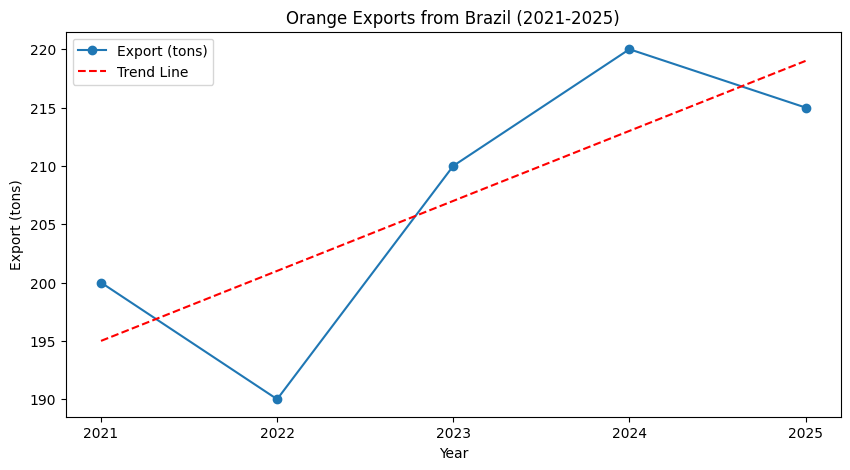

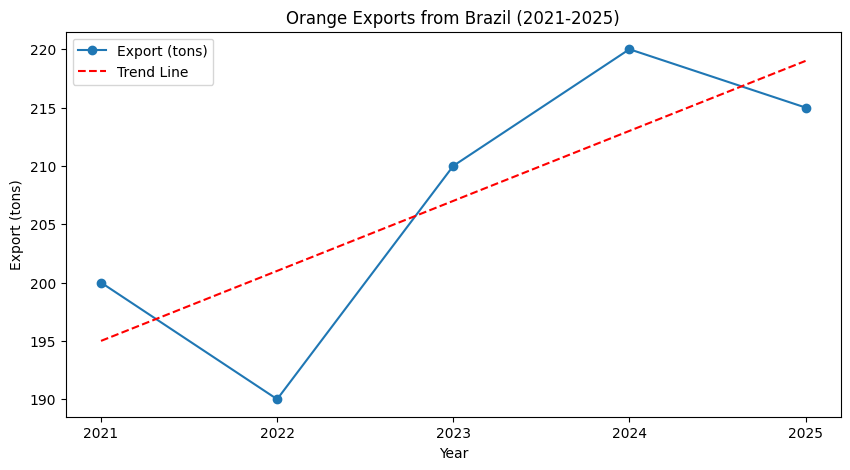

In [57]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.2,
)

search_tool = DuckDuckGoSearchRun()

python_repl = PythonREPL()
python_tool = Tool(
    name="python_repl",
    description="A Python shell. Use this to execute python commands. Input should be a valid python command. If you want to see the output of a value, you necessarily should print it out with `print(...)`. Otherwise you won't see the result! It's very important.",
    func=python_repl.run,
)
python_tool.name = "python_interpreter"

tools = [search_tool, python_tool, weather_brazil]

system_prompt = """
You are a Business Analytics Agent.

TOOLS:
- Python (for calculations, tables)
- Web search (for demand, inflation, weather)
- Weather API (Brazil)

When generating the forecast for 2025:

1. Parse numeric historical data from user text.
2. Use Python tool to calculate:
   - Trend (year, export_tons)
   - Average growth / regression
3. Use Python tool to output a TABLE in plain text:

   Year | Export (tons)
   -----|--------------
   2021 | ...
   2022 | ...
   2023 | ...
   2024 | ...

4. Use Python tool to BUILD A GRAPH:
   - X axis: year
   - Y axis: export tons
   - Include the linear trend line
   - Save graph to a PNG file and return base64-encoded string

5. Use weather + web search tools to adjust forecast.

6. Your FINAL ANSWER MUST CONTAIN:
   - "Forecast for 2025: <number> tons"
   - The TABLE (generated via Python tool)
   - Short explanation of factors (weather, demand, economy)
"""

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=system_prompt,
)

user_query = """
We export oranges from Brazil.
In 2021, 200 tons were exported,
in 2022 - 190 tons,
in 2023 - 210 tons,
in 2024, which has not yet ended - 220 tons.

Estimate how many oranges we can export in 2025
given the weather conditions in Brazil and the demand for oranges in the world
based on the economic situation.
"""

result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": user_query
        }
    ]
})

print(result["messages"][-1].content)